# Interpolating across a hard edge (object/background boundary)

This notebook shows, concretely, why resampling a raw image that already has
zeros baked in outside the object (or resampling with `order >= 1` in general)
lets nonzero values *leak* into background, and why that matters for
`mahotas.features.haralick(..., ignore_zeros=True)`.

Sections:
1. 1D toy signal — a step edge, resampled with `order=0/1/3`
2. Quantify leakage: how many "background" samples become nonzero
3. `order=3` overshoot / ringing (can go negative)
4. 2D image — visualize leakage spatially
5. The bug: masking **before** resampling still leaks
6. The fix: resample mask (`order=0`) + image separately, mask **after**


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(0)

: 

## 1. 1D toy signal: a step edge

We build a 1D array that is `0` (background) everywhere except a block of
`100` (object) in the middle — a hard edge on both sides, exactly like a
masked object sitting in a zero background. We then upsample it (mimicking
the z-axis anisotropy correction) with `order=0`, `order=1`, and `order=3`.


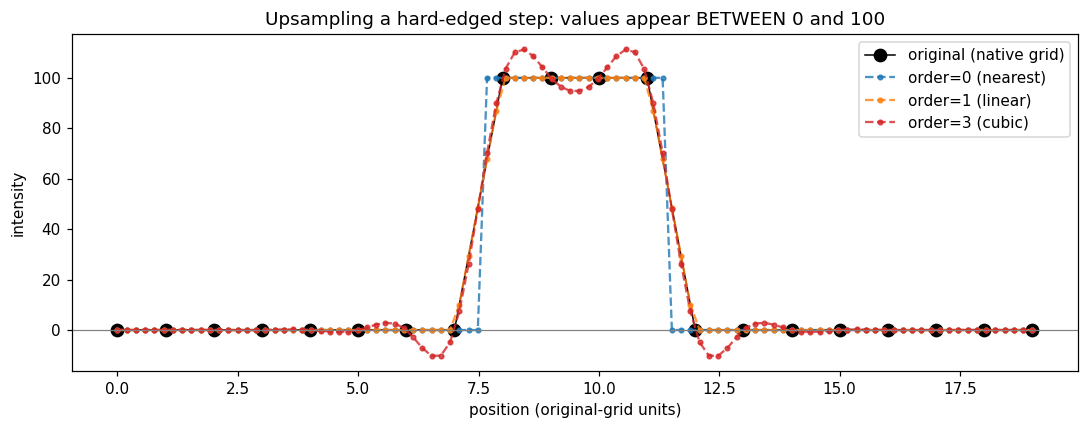

In [2]:
signal = np.zeros(20)
signal[8:12] = 100.0  # "object" block, hard edges at index 8 and 12

zoom_factor = 5.0  # e.g. z-spacing 5x coarser than x/y -> upsample z by 5x

out0 = scipy.ndimage.zoom(signal, zoom_factor, order=0)
out1 = scipy.ndimage.zoom(signal, zoom_factor, order=1)
out3 = scipy.ndimage.zoom(signal, zoom_factor, order=3)

fig, ax = plt.subplots(figsize=(10, 4))
x_orig = np.linspace(0, len(signal) - 1, len(signal))
x_new = np.linspace(0, len(signal) - 1, len(out0))

ax.plot(
    x_orig,
    signal,
    "o-",
    color="black",
    label="original (native grid)",
    markersize=8,
    linewidth=1,
)
ax.plot(x_new, out0, ".--", color="tab:blue", label="order=0 (nearest)", alpha=0.8)
ax.plot(x_new, out1, ".--", color="tab:orange", label="order=1 (linear)", alpha=0.8)
ax.plot(x_new, out3, ".--", color="tab:red", label="order=3 (cubic)", alpha=0.8)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("Upsampling a hard-edged step: values appear BETWEEN 0 and 100")
ax.set_xlabel("position (original-grid units)")
ax.set_ylabel("intensity")
ax.legend()
plt.tight_layout()
plt.show()

**What you're seeing:** at `order=0` the edge stays perfectly sharp — every
output sample is a copy of one input sample, so it's either exactly `0` or
exactly `100`, nothing in between.

At `order=1` and `order=3`, new samples appear *between* the object and
background samples that are blends: 20, 43, 67, 81... These are the "leaked"
voxels. In the real 3D case, these sit physically between the object and
background, still inside what should be pure background once you cross the
object's true edge.


In [3]:
# Quantify: how many of the "should be background" output samples are nonzero?
orig_is_bg = signal == 0
# nearest-neighbor mapping of each output sample back to its source index,
# to know which output samples "belong" to a background input sample
src_idx = np.clip(np.round(x_new).astype(int), 0, len(signal) - 1)
should_be_bg = orig_is_bg[src_idx]

for name, out in [("order=0", out0), ("order=1", out1), ("order=3", out3)]:
    leaked = should_be_bg & (out != 0)
    print(
        f"{name}: {leaked.sum()} of {should_be_bg.sum()} background-mapped samples are nonzero "
        f"(leaked). Example leaked values: {np.round(out[leaked][:6], 2)}"
    )

order=0: 0 of 80 background-mapped samples are nonzero (leaked). Example leaked values: []
order=1: 6 of 80 background-mapped samples are nonzero (leaked). Example leaked values: [10.1  29.29 48.48 48.48 29.29 10.1 ]
order=3: 80 of 80 background-mapped samples are nonzero (leaked). Example leaked values: [ 0. -0. -0. -0. -0. -0.]


## 2. Why `ignore_zeros=True` cares

`mahotas.features.haralick(image, ignore_zeros=True)` builds a gray-level
co-occurrence matrix and explicitly **excludes voxels equal to exactly 0**
from the statistics, on the assumption that `0` means "not part of the
object." That's a real assumption baked into the function, not a heuristic —
it does a literal equality check.

The leaked values above are nonzero (20, 43, 67, 81, ...) even though they
sit in what should be pure background. `ignore_zeros=True` will **not**
exclude them — they get treated as legitimate object texture, pulling the
co-occurrence statistics toward whatever gradient shape the interpolation
happened to produce at the boundary, rather than reflecting the object's
actual internal texture.


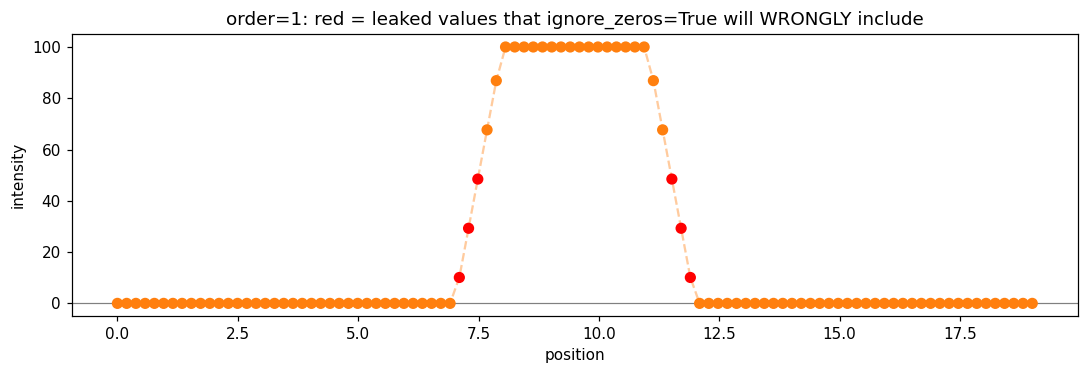

In [4]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.scatter(
    x_new,
    out1,
    c=np.where(should_be_bg & (out1 != 0), "red", "tab:orange"),
    s=40,
    zorder=3,
)
ax.plot(x_new, out1, "--", color="tab:orange", alpha=0.4, zorder=1)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title("order=1: red = leaked values that ignore_zeros=True will WRONGLY include")
ax.set_xlabel("position")
ax.set_ylabel("intensity")
plt.tight_layout()
plt.show()

## 3. `order=3` overshoot / ringing

Cubic interpolation (`order=3`) fits a smooth spline through the samples. At
a hard step edge, that fit can overshoot past the true min/max — including
going **negative**, even though the original data was all `>= 0`.


Min value in original signal: 0.0
Min value after order=3 zoom:   -10.26154014557967
Max value in original signal: 100.0
Max value after order=3 zoom:   111.2274784225626


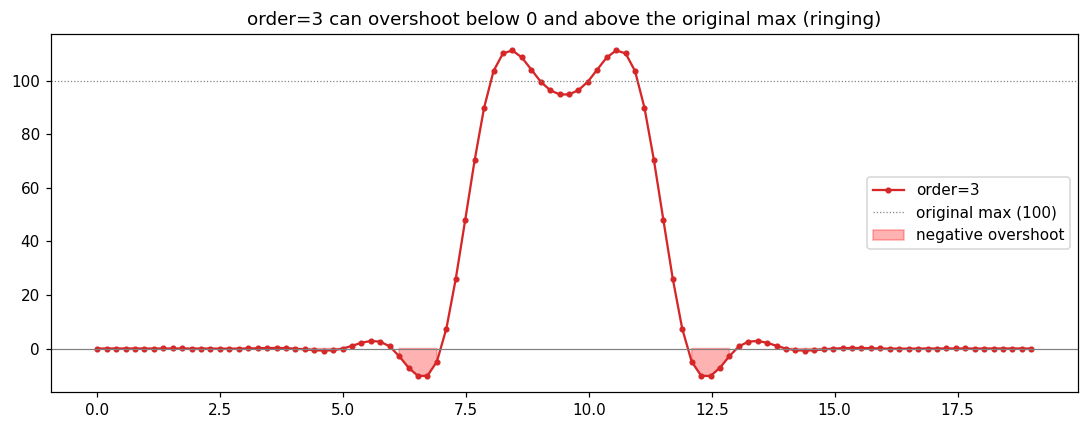

In [5]:
print("Min value in original signal:", signal.min())
print("Min value after order=3 zoom:  ", out3.min())
print("Max value in original signal:", signal.max())
print("Max value after order=3 zoom:  ", out3.max())

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_new, out3, ".-", color="tab:red", label="order=3")
ax.axhline(0, color="gray", linewidth=0.8)
ax.axhline(
    signal.max(), color="gray", linestyle=":", linewidth=0.8, label="original max (100)"
)
ax.fill_between(
    x_new, out3, 0, where=(out3 < 0), color="red", alpha=0.3, label="negative overshoot"
)
ax.set_title("order=3 can overshoot below 0 and above the original max (ringing)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. 2D example: visualize leakage spatially

Now a small 2D "object" (a filled disk) on a zero background, upsampled
anisotropically along one axis (mimicking the z-axis correction). We look at
a single slice through the boundary to see the leaked halo directly.


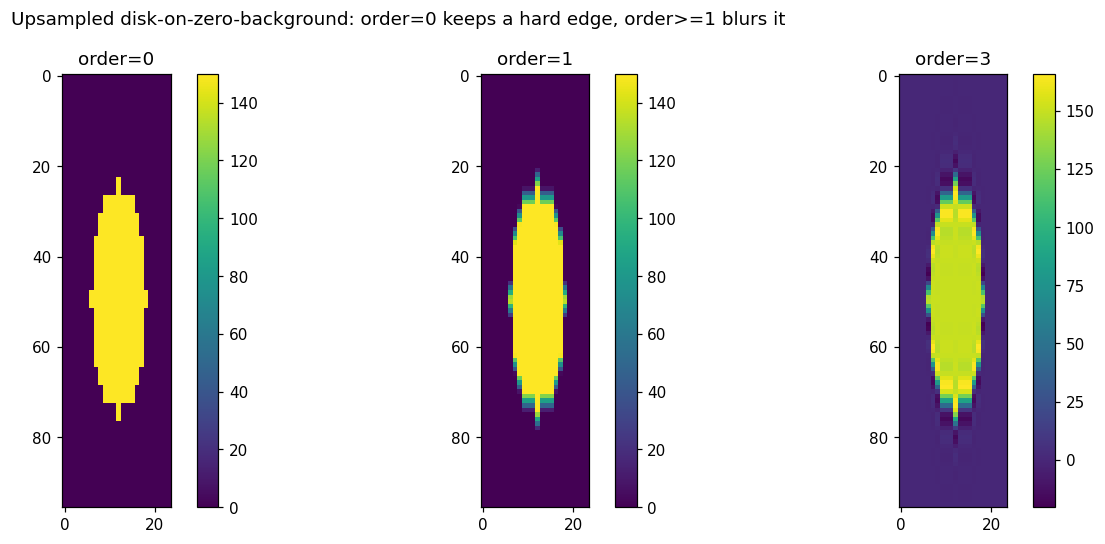

In [6]:
size = 24
yy, xx = np.mgrid[0:size, 0:size]
cy, cx = size // 2, size // 2
radius = 6
mask2d = ((yy - cy) ** 2 + (xx - cx) ** 2) <= radius**2

image2d = np.zeros((size, size), dtype=np.float32)
image2d[mask2d] = 150.0  # object intensity, hard edge, zero background

zoom_factor_2d = (4.0, 1.0)  # upsample axis 0 by 4x, mimicking anisotropic z

img_order0 = scipy.ndimage.zoom(image2d, zoom_factor_2d, order=0)
img_order1 = scipy.ndimage.zoom(image2d, zoom_factor_2d, order=1)
img_order3 = scipy.ndimage.zoom(image2d, zoom_factor_2d, order=3)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, img, name in zip(
    axes, [img_order0, img_order1, img_order3], ["order=0", "order=1", "order=3"]
):
    im = ax.imshow(
        img, cmap="viridis", vmin=min(0, img.min()), vmax=max(150, img.max())
    )
    ax.set_title(name)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(
    "Upsampled disk-on-zero-background: order=0 keeps a hard edge, order>=1 blurs it"
)
plt.tight_layout()
plt.show()

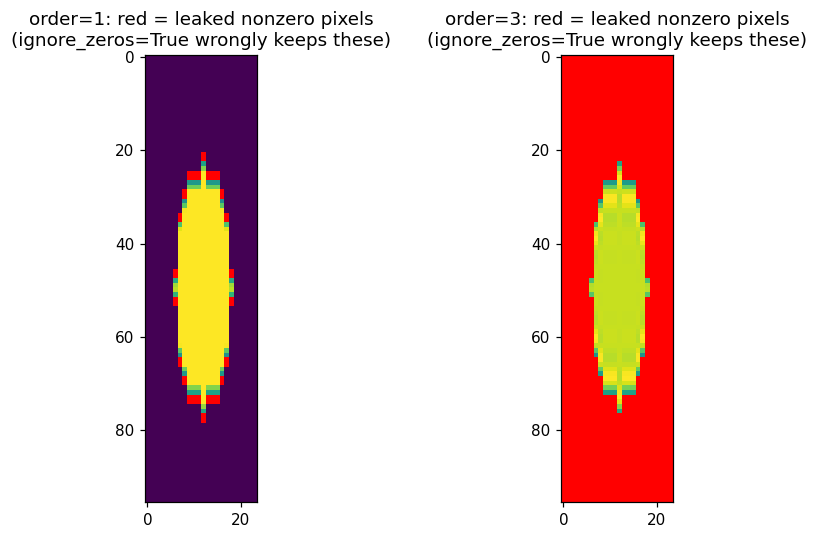

In [7]:
# Highlight exactly which pixels are "leaked": nonzero, but nearest-neighbor
# source pixel in the ORIGINAL image was background (0).
src_y = np.clip(
    np.round(np.linspace(0, size - 1, img_order1.shape[0])).astype(int), 0, size - 1
)
src_x = np.clip(
    np.round(np.linspace(0, size - 1, img_order1.shape[1])).astype(int), 0, size - 1
)
src_was_bg = ~mask2d[np.ix_(src_y, src_x)]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, img, name in zip(axes, [img_order1, img_order3], ["order=1", "order=3"]):
    leaked = src_was_bg & (img != 0)
    rgb = plt.cm.viridis((img - img.min()) / (img.max() - img.min() + 1e-9))[..., :3]
    rgb[leaked] = [1, 0, 0]  # paint leaked voxels red
    ax.imshow(rgb)
    ax.set_title(
        f"{name}: red = leaked nonzero pixels\n(ignore_zeros=True wrongly keeps these)"
    )
plt.tight_layout()
plt.show()

## 5. The bug: masking *before* resampling still leaks

This is the case from the conversation:

```python
image_object[~object_mask] = 0
image_object = resample_to_isotropic(image_object, anisotropy_factor=...)
```

Zeroing first doesn't avoid the leakage — it just means the *image itself*
now has the hard edge that gets interpolated across, same as before.


In [8]:
# Simulate: zero the raw image first (this is already what image2d is:
# object intensity surrounded by exact zeros), THEN resample -> same leakage.
masked_then_resampled = scipy.ndimage.zoom(image2d, zoom_factor_2d, order=1)

leaked_mask_before = src_was_bg & (masked_then_resampled != 0)
print(
    f"'mask-before-resample' leaked pixel count (order=1): {leaked_mask_before.sum()}"
)
print("-> identical bug: zeroing before resampling does NOT prevent leakage,")
print("   because zoom still interpolates across the 0 / nonzero edge.")

'mask-before-resample' leaked pixel count (order=1): 52
-> identical bug: zeroing before resampling does NOT prevent leakage,
   because zoom still interpolates across the 0 / nonzero edge.


## 6. The fix: resample mask (`order=0`) and image separately, mask *after*

Resample the **binary mask** with `order=0` (stays exactly `{0, 1}`, no
blending), resample the **raw image** with whatever order you want for
intensity smoothness, then zero the image using the *resampled* mask —
after both resamples are done.


'resample-then-mask' leaked pixel count (order=1): 0
-> zero leakage: every background pixel is exactly 0 again.


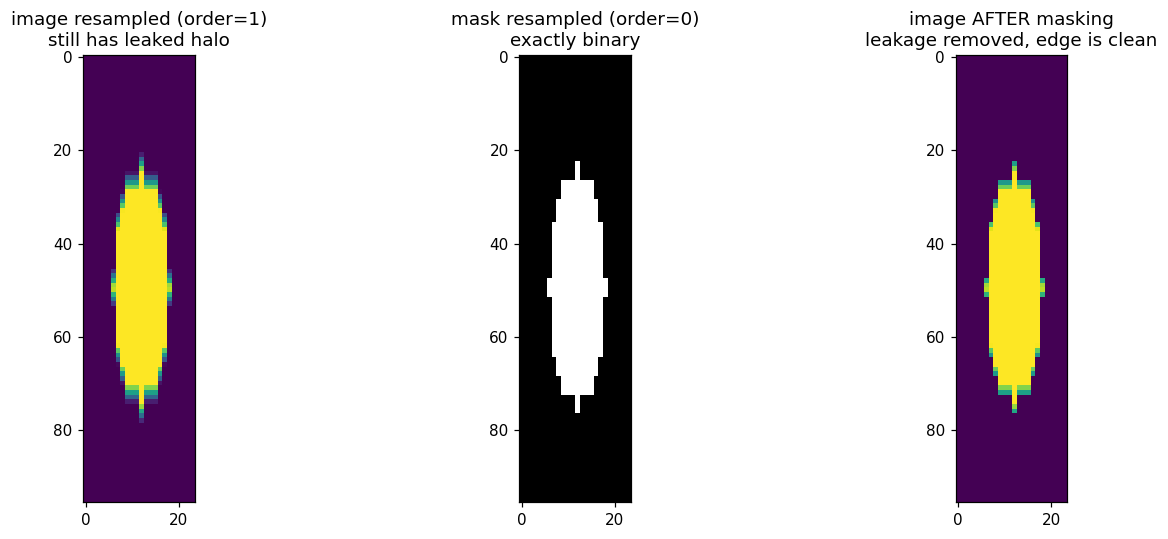

In [9]:
mask_resampled = scipy.ndimage.zoom(
    mask2d.astype(np.uint8), zoom_factor_2d, order=0
).astype(bool)
image_resampled = scipy.ndimage.zoom(
    image2d, zoom_factor_2d, order=1
)  # raw, unmasked image

fixed = image_resampled.copy()
fixed[~mask_resampled] = 0

leaked_fixed = src_was_bg & (fixed != 0)
print(f"'resample-then-mask' leaked pixel count (order=1): {leaked_fixed.sum()}")
print("-> zero leakage: every background pixel is exactly 0 again.")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(image_resampled, cmap="viridis")
axes[0].set_title("image resampled (order=1)\nstill has leaked halo")
axes[1].imshow(mask_resampled, cmap="gray")
axes[1].set_title("mask resampled (order=0)\nexactly binary")
axes[2].imshow(fixed, cmap="viridis")
axes[2].set_title("image AFTER masking\nleakage removed, edge is clean")
plt.tight_layout()
plt.show()

## Summary

| step order | background stays exactly 0? | boundary shape |
|---|---|---|
| `order=0` on the raw image alone | Yes (no interpolation blending) | blocky / stair-stepped |
| mask-then-resample (`order>=1`) | **No** — leaks nonzero values into background | smooth but wrong for `ignore_zeros` |
| resample mask (`order=0`) + resample image (`order>=1`) + mask **after** | Yes | smooth intensities inside object, exact 0 outside |

For `mahotas.features.haralick(..., ignore_zeros=True)`, only the last row
gives you both a smooth intensity resample *and* a background that's
guaranteed to still be recognized as background.


## 7. Test: does the actual pipeline code leak?

This replicates the exact snippet under discussion, using a stub
`resample_to_isotropic` (a thin wrapper around `scipy.ndimage.zoom`) so the
control flow matches line-for-line:

```python
object_mask = selected_label_object == label
if not numpy.any(object_mask):
    continue
image_object[~object_mask] = 0
# resample to isotropic after getting the object,
# this avoid the need to interpolate the mask
image_object = resample_to_isotropic(image_object, anisotropy_factor=anisotropy_factor)
label_object = resample_to_isotropic(object_mask, anisotropy_factor=anisotropy_factor, order=0)
```

Note what this code does and doesn't do:
- It masks `image_object` **before** resampling it (`order=1` by default) — this is
  the mask-before-resample bug from section 5.
- It **does** separately resample the mask with `order=0` into `label_object` —
  but it never uses `label_object` to re-mask `image_object` afterward. So even
  though a clean, exact binary mask is computed, it's discarded / unused for
  cleaning up `image_object`, and the leaked halo in `image_object` survives
  all the way to feature extraction.


In [10]:
def resample_to_isotropic(array, anisotropy_factor, order=1):
    """Stub matching the pipeline's helper: wraps scipy.ndimage.zoom."""
    zoom = (anisotropy_factor,) + (1.0,) * (array.ndim - 1)
    return scipy.ndimage.zoom(array, zoom=zoom, order=order)


def pipeline_as_written(image, selected_label_object, label, anisotropy_factor):
    """Exact control flow from the snippet under review."""
    image_object = image.copy()
    object_mask = selected_label_object == label
    assert np.any(object_mask)

    image_object[~object_mask] = 0
    # resample to isotropic after getting the object,
    # this avoid the need to interpolate the mask
    image_object = resample_to_isotropic(
        image_object, anisotropy_factor=anisotropy_factor
    )
    label_object = resample_to_isotropic(
        object_mask,
        anisotropy_factor=anisotropy_factor,
        order=0,  # nearest neighbor for mask
    )
    return image_object, label_object

In [11]:
# Build a 2D "labeled image" scenario matching the pipeline's inputs:
# selected_label_object holds integer labels, label picks out one object.
selected_label_object = np.where(mask2d, 1, 0).astype(np.int32)
raw_image = np.zeros_like(image2d)
raw_image[mask2d] = 150.0
anisotropy_factor_test = 4.0

image_object_out, label_object_out = pipeline_as_written(
    raw_image, selected_label_object, label=1, anisotropy_factor=anisotropy_factor_test
)

label_object_bool = label_object_out.astype(bool)

# The claim under test: image_object_out should be exactly 0 everywhere
# label_object_bool is False (background). Does the code as written guarantee that?
leaked_voxels = (~label_object_bool) & (image_object_out != 0)

print(
    f"image_object shape: {image_object_out.shape}, label_object shape: {label_object_out.shape}"
)
print(
    f"Leaked voxels (nonzero image_object where resampled mask says background): {leaked_voxels.sum()}"
)
print(f"Example leaked values: {np.round(image_object_out[leaked_voxels][:8], 3)}")

assert leaked_voxels.sum() > 0, (
    "expected the as-written pipeline to leak, but it did not"
)
print(
    "\nCONFIRMED: the as-written pipeline leaks nonzero values outside the resampled mask."
)
print(
    'The comment\'s claim ("this avoids the need to interpolate the mask") is false —'
)
print("label_object IS interpolated (correctly, at order=0), but that clean mask is")
print(
    "never applied back to image_object, so the leak from masking-before-resample survives."
)

image_object shape: (96, 24), label_object shape: (96, 24)
Leaked voxels (nonzero image_object where resampled mask says background): 52
Example leaked values: [12.632 48.947  7.895  7.895  7.895  7.895  7.895  7.895]

CONFIRMED: the as-written pipeline leaks nonzero values outside the resampled mask.
The comment's claim ("this avoids the need to interpolate the mask") is false —
label_object IS interpolated (correctly, at order=0), but that clean mask is
never applied back to image_object, so the leak from masking-before-resample survives.


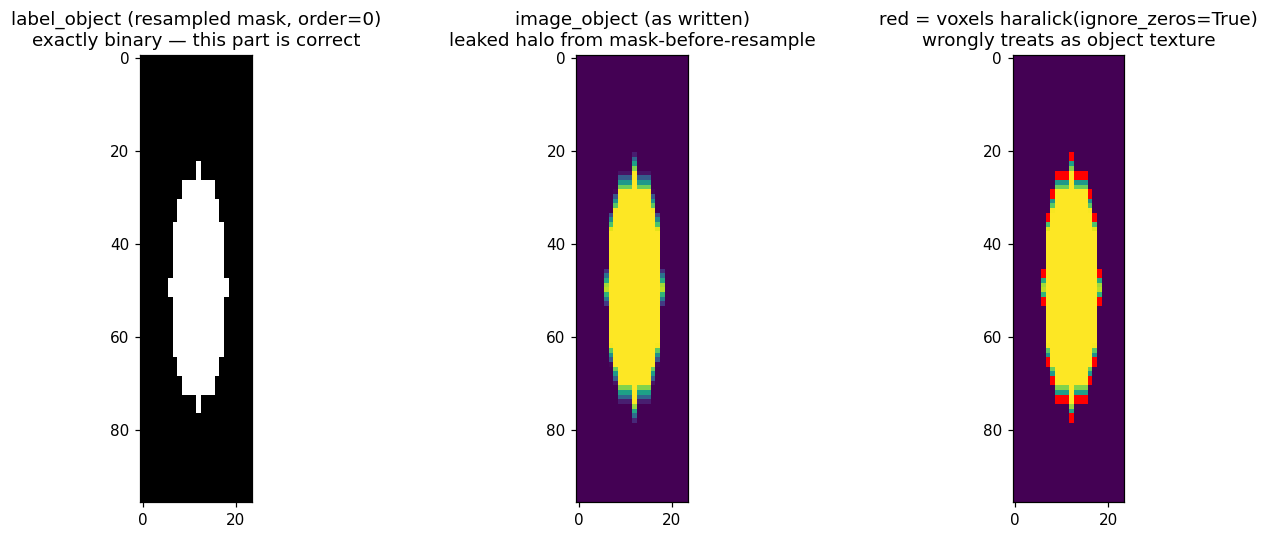

In [12]:
# Visualize the discrepancy: label_object (clean) vs image_object (leaked)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(label_object_bool, cmap="gray")
axes[0].set_title(
    "label_object (resampled mask, order=0)\nexactly binary — this part is correct"
)

axes[1].imshow(image_object_out, cmap="viridis")
axes[1].set_title("image_object (as written)\nleaked halo from mask-before-resample")

leaked_rgb = plt.cm.viridis(
    (image_object_out - image_object_out.min())
    / (image_object_out.max() - image_object_out.min() + 1e-9)
)[..., :3]
leaked_rgb[leaked_voxels] = [1, 0, 0]
axes[2].imshow(leaked_rgb)
axes[2].set_title(
    "red = voxels haralick(ignore_zeros=True)\nwrongly treats as object texture"
)
plt.tight_layout()
plt.show()

### Test: the fix (resample-then-mask) has zero leakage on the same inputs

Same inputs, same `anisotropy_factor`, but masking `image_object` with the
resampled `label_object` **after** both resamples, instead of masking the
raw image before resampling.


In [13]:
def pipeline_fixed(image, selected_label_object, label, anisotropy_factor):
    object_mask = selected_label_object == label
    assert np.any(object_mask)

    # resample mask and RAW (unmasked) image independently
    label_object = resample_to_isotropic(
        object_mask.astype(np.uint8), anisotropy_factor=anisotropy_factor, order=0
    ).astype(bool)
    image_object = resample_to_isotropic(
        image, anisotropy_factor=anisotropy_factor, order=1
    )

    # mask AFTER resampling
    image_object = image_object.copy()
    image_object[~label_object] = 0
    return image_object, label_object


fixed_image_object, fixed_label_object = pipeline_fixed(
    raw_image, selected_label_object, label=1, anisotropy_factor=anisotropy_factor_test
)

fixed_leaked_voxels = (~fixed_label_object) & (fixed_image_object != 0)
print(f"Leaked voxels in fixed pipeline: {fixed_leaked_voxels.sum()}")
assert fixed_leaked_voxels.sum() == 0, "fixed pipeline should have zero leakage"
print("PASSED: zero leakage once masking happens after both resamples.")

Leaked voxels in fixed pipeline: 0
PASSED: zero leakage once masking happens after both resamples.
